# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

R.De users, el 11.72% son valores nulos en city y 88.35% de churn_date.
De Usage, date tiene 0.12% de valorws nulos, pero duración tienen el 55.19% y lenght el 44.74%
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

R. En un primer analisis, en el csv Users; churn_date debe aliminarse ya que esta vacía casi por completo, mientras que city podría investigarse para imputar o dejar nulo. Para usage, se puede imputar los faltantes de Date y parecriera por la cantidad de datos faltantes y los nombres de las columnas que es posible que los datos faltantes de 'duration' estén en 'lenght'. Haria falta una simple confirmación para poder continuar con el analisis en esos rubros.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users_num_cols=['user_id', 'age']
for col in users_num_cols:
    print(col)
    print(users[col].describe())
    print(users[col].value_counts())
    print()

user_id
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
10241    1
11583    1
13604    1
11559    1
13608    1
        ..
10916    1
12967    1
10920    1
12971    1
10239    1
Name: user_id, Length: 4000, dtype: int64

age
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
50    86
30    81
78    79
33    74
36    74
      ..
57    54
51    54
62    51
68    51
70    45
Name: age, Length: 63, dtype: int64



- La columna `user_id` vemos que los id empiezan desde el 10000, terminan en 13999. Al ser IDs, es predecible una dispersion alta. No parece haber valores duplicados.
- La columna `age` muestra sentinels que afectan el valor del promedio y la dispersion.

In [13]:
# explorar columnas numéricas de usage
usage_num_cols=['id', 'user_id', 'duration', 'length']
for col in usage_num_cols:
    print(col)
    print(usage[col].describe())
    print(usage[col].value_counts())
    print()

id
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
2049     1
35492    1
25241    1
31386    1
29339    1
        ..
17730    1
19779    1
30020    1
32069    1
2047     1
Name: id, Length: 40000, dtype: int64

user_id
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64
13819    27
13100    22
13772    22
13255    22
13475    21
         ..
12448     2
11891     2
10226     2
13923     2
12058     1
Name: user_id, Length: 3999, dtype: int64

duration
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64
0.21     47
0.03     43
1.25     43
0.0

- Las columnas `id` y `user_id` no parecen tener mayores afectaciones y en un primer acercamiento no parecen tener sentinels.
- Las columnas `duration` y `lenght`, ademas de tener muchos datos nulos, aparentemente ambos tienen `ouliers` que requeria un analisis más profundo.

In [14]:
# explorar columnas categóricas de users
users_categoric_cols = ['city', 'plan']
for col in users_categoric_cols:
    print(col)
    print(users[col].describe())
    print(users[col].value_counts())
    print()


city
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` muestra que, además de los valores nulos hay sentinels, por lo que requiere analizar si de alguna forma pueden imputarse o si es necesario dropearlos.
- La columna `plan` no muestra ninguna alteración, más alla de la curiosidad que casi el doble de los usuarios usan el plan basico.

In [15]:
# explorar columna categórica de usage
print(usage['type'].describe())
print(usage['type'].value_counts())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` tampoco muestra una alteración importante. Ni sentinels ni valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

R.Solo age y city parecen tener sentinels, quizas valdría la pena una confrimación si el 0 en `duration`y `length` es un sentinel o caso que se consideran al no contestar o bloquear la llamada.

- ¿Qué acción tomarías?

R. Las columnas no tienen redundancia y no es posible deducir la informacion a partir de otras columnas. Quizas sea mejor quitar sentinels y usar medianas en los casos que sean posibles.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce", utc=True)

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce", utc=True)

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date_year']= users['reg_date'].dt.year
usage['date_year']=usage['date'].dt.year

print(users['reg_date_year'].value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date_year, dtype: int64


En `reg_date`, hay aparicion de fechas de registro más antiguas que el rango, pero no suponen un problema. Tambien hay fechas imposibles (2026).

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date_year'].value_counts())

2024.0    39950
Name: date_year, dtype: int64


En `date`, todas las fechas muestran el rango solicitado, no necesitan ningun tratamiento.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?

R. Solo en `users`.

- ¿Qué harías con ellas?

R. No pueden considerarse dentro del analisis, por ser años que aun no transcurren.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
print(users['city'].describe())
print(users['city'].value_counts())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
for fecha in users['reg_date']:
    if fecha.year==2026:
        users['reg_date']= users['reg_date'].replace(fecha,pd.NA)

users['reg_date_year']=users['reg_date_year'].replace(2026,pd.NA)

# Verificar cambios
print(users['reg_date'].dt.year.describe())
print(users['reg_date'].dt.year.value_counts())


count    3960.000000
mean     2023.004040
std         0.817208
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2024.000000
Name: reg_date, dtype: float64
2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

R. Parece que el Dataset Usage divide la duración entre texto y llamadas, por lo que confirmamos que hay dependencia de `duration`y `length` con `type`.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')['is_text','is_call','length'].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,length
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [26]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "length": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,258.0
1,10001,5,10,226.0
2,10002,5,2,225.0


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on='user_id',how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,258.0
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
profile_num_cols=['user_id','age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in profile_num_cols:
    print(col)
    print(user_profile[col].describe())
    print()

user_id
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

age
count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

cant_mensajes
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

cant_llamadas
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

cant_minutos_llamada
count    3999.000000
mean      288.128032
std       180.906841
min         0.000000
25%       184.000000
50%       268.000000
7

In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo: 
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

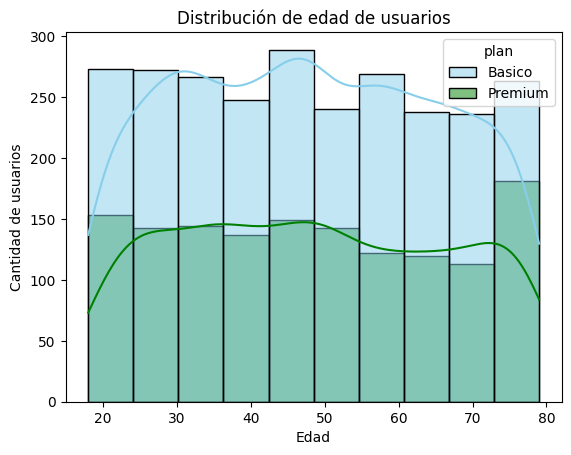

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age',hue='plan',bins=10,palette=['skyblue','green'],kde=True)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad de usuarios')
plt.show()

💡Insights: 

- Distribución simetrica, el promedio ronda los 48, alta dispersion.
- Un aumento considerable en usuarios menores a los 30 y mayores a los 75.
- Los usuarios premium que dominan estan arriba de los 75 años. No se vislumbra outliers.


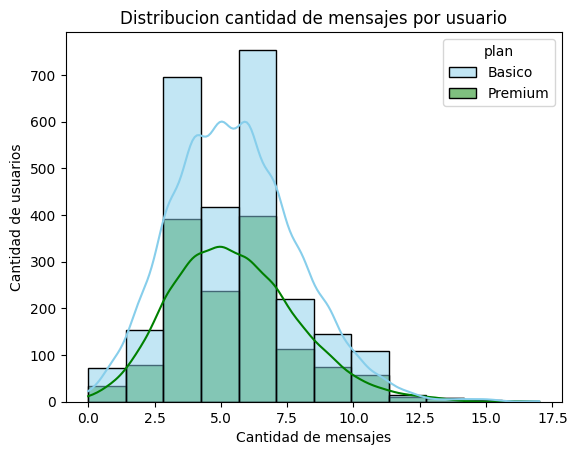

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes',hue='plan',bins=12,palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion cantidad de mensajes por usuario')
plt.show()

💡Insights: 

- Distribución sesgada a la derecha, el promedio ronda los 5 mensajes, sin embargo no cuenta toda la historia, media disperción.
- Los mensajes siguen un mismo patron independientemente del plan. Esto quiere decir que tener un plan basico o premium no afecta el numero de mensajes enviados o recibidos.
- Visualizamos extremos superiores a la derecha `outliers`.


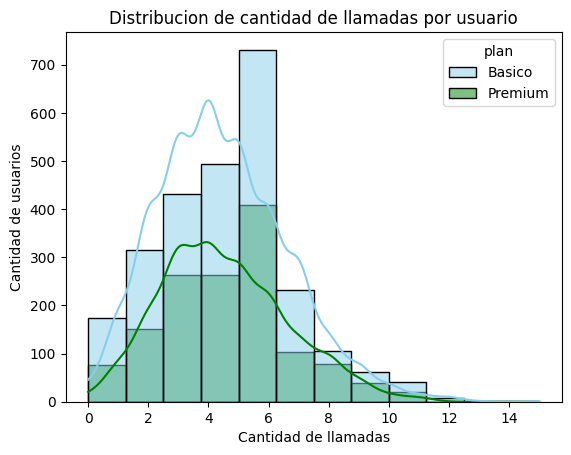

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x='cant_llamadas',hue='plan',bins=12,palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion de cantidad de llamadas por usuario')
plt.show()

💡Insights: 

- Distribución sesgada a la derecha, el promedio ronda las 4 llamadas en estadistica, pero vemos que no refleja la realidad, media dispersión.
- Igual que los mensajes, no hay una clara diferencia entre el patron de los que tienen un plan basico a uno premium. Esto indica que el plan basico no hace que la gente haga o reciba más llamadas, y viceversa.
- Visualizamos extremos superiores a la derecha `outliers`.


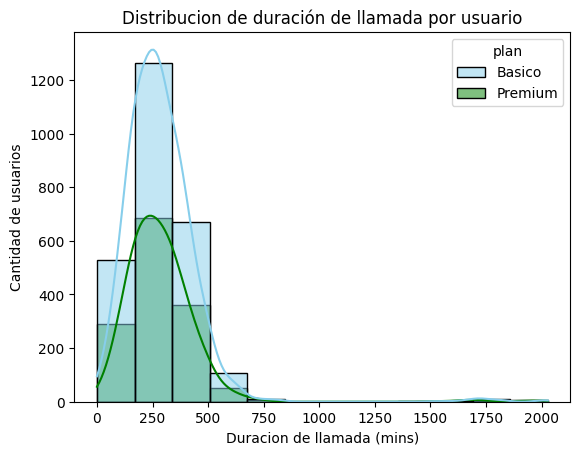

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='cant_minutos_llamada',hue='plan',bins=12,palette=['skyblue','green'],kde=True)
plt.xlabel('Duracion de llamada (mins)')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion de duración de llamada por usuario')
plt.show()

💡Insights: 
- Distribución muy sesgada a la derecha, el promedio ronda las 288 minutos por llamada en estadistica, pero vemos que hay una ligera desviación, baja dispersion.
- El plan basico o premium no influye en la duración de las llamadas.
- Visualizamos extremos superiores a la derecha `outliers`.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

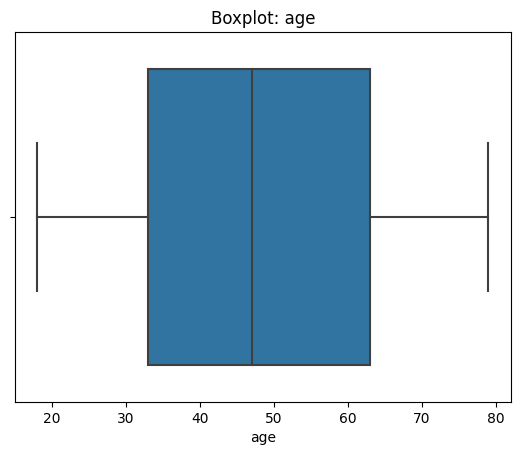

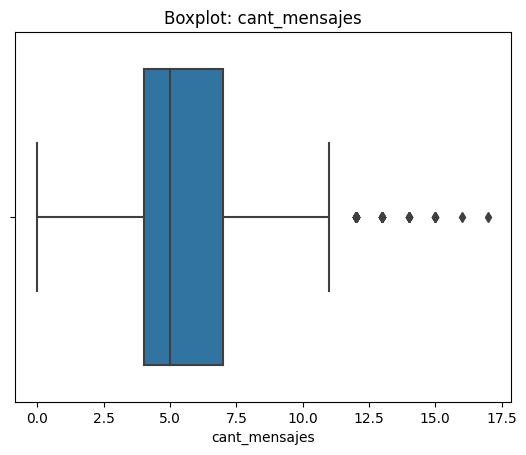

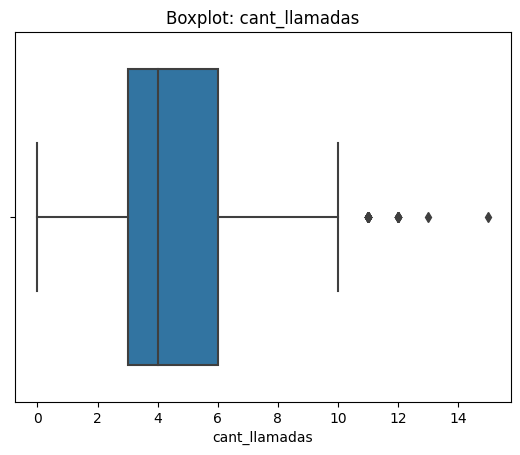

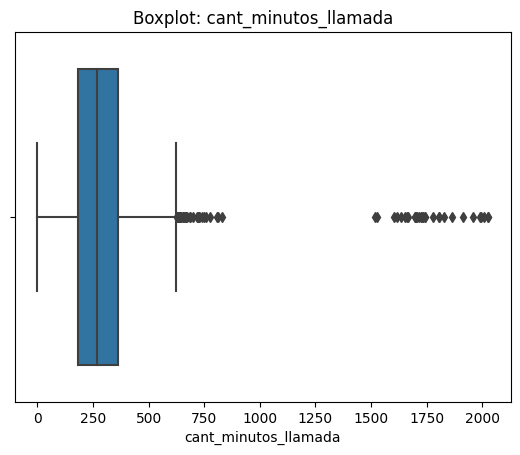

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: Presenta outliers pero no son muy extremos.
- cant_llamadas: Presenta outliers pero no son muy extremos.
- cant_minutos_llamada: Presenta outliers extremos.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    q1=user_profile[col].quantile(0.25)
    q3=user_profile[col].quantile(0.75)
    iqr=q3-q1
    upper=q3+(1.5*iqr)
    print(col)
    print('Q1:',q1)
    print('Q3:',q3)
    print('IQR:',iqr)
    print('Limite superior:',upper)
    print()



cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Limite superior: 11.5

cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Limite superior: 10.5

cant_minutos_llamada
Q1: 184.0
Q3: 361.0
IQR: 177.0
Limite superior: 626.5



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,288.128032
std,2.358416,2.144238,180.906841
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,184.000000
50%,5.000000,4.000000,268.000000
75%,7.000000,6.000000,361.000000
max,17.000000,15.000000,2028.000000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

R. Se pueden mantener pues no representan un valor que suguiera un error. En su defecto se pueden winsorizar.

- cant_llamadas: mantener o no outliers, porqué?

R. Se pueden mantener pues no representan un valor que suguiera un error. En su defecto se pueden winsorizar.

- cant_minutos_llamada: mantener o no outliers, porqué?

R. Aqui valdría la pena un analisis más profundo, ya que se puede tratar de fraude o errores de registro. Para el analisis general se podrían eliminar, pero si tenerlos bien documentados.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
def clasif_x_uso(row):
    if (row['cant_mensajes']<5 and row['cant_llamadas'] <5):
        return 'Bajo uso'
    elif (row['cant_mensajes']<10 and row['cant_llamadas'] <10):
        return 'Uso medio'
    else:
        return 'Alto uso'

In [38]:
# Crear columna grupo_uso
user_profile['grupo_uso']=user_profile.apply(clasif_x_uso,axis=1)

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,258.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
def clasif_x_edad(row):
    if row['age']<30:
        return 'Joven'
    elif row['age']<60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

In [41]:
# Crear columna grupo_edad
user_profile['grupo_edad']=user_profile.apply(clasif_x_edad,axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

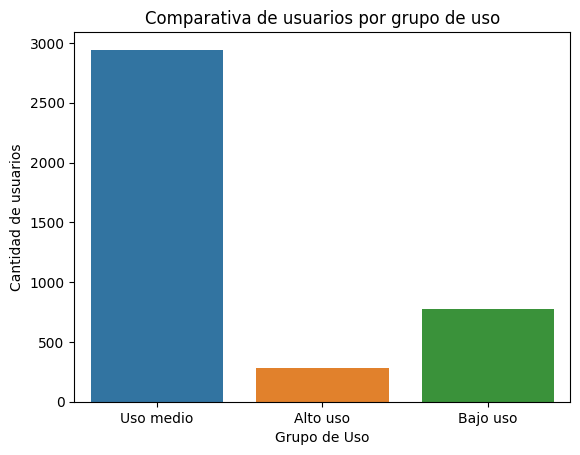

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x='grupo_uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de usuarios')
plt.title('Comparativa de usuarios por grupo de uso')
plt.show()

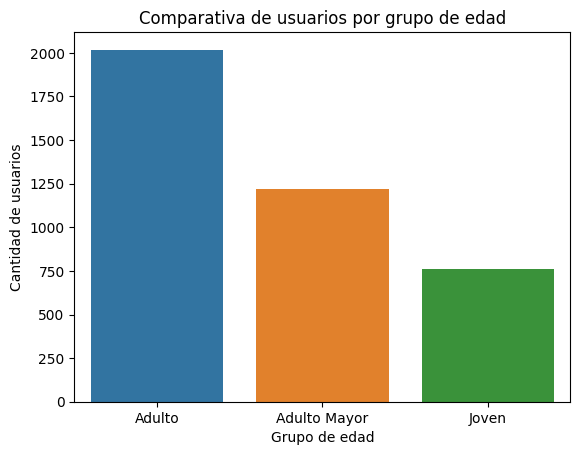

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Comparativa de usuarios por grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los problemas encontrados en los Dataset fueron valores faltantes, sentinelas y outliers. De los 3 datasets, solo `plan.csv` estaba limpio.
- `Users.csv` tenia un 11.72% de valores nulos en su columna `city`, junto con 96 valores sentinel.
    - Tambien en su columna `age` tenía valores sentinel, pero estaban completos.
- `Usage.csv` tenía los valores de `duration` correspondiente al tiempo de mensajes y `lenght`correspondiente al tiempo de llamadas. 


🔍 **Segmentos por Edad**
- En segmentos de clientes, la mayoría adquiere un plan basico, sin embargo encontre un ligero aumento de paquetes premium en adultos mayores.
- Aunque la mayoría de los clientes son adultos, una porcion importante, alrededor del 30%, son adultos mayores y un 25% jovenes. 


📊 **Segmentos por Nivel de Uso**
- Casi el 75% de los clientes son de uso medio, un 20% es de uso bajo y aproximadamente un 5% es de alto uso.
- La diferencia en paquetes no altera patrones de cantidad de llamadas o mensajes, tampoco la duración en las llamadas.


➡️ Esto sugiere que ...

- La nula diferencia en los patrones de uso de mensajes y llamadas habla de poca ventaja que tiene el paquete premium vs el basico en esos rubros.
- El mercado más grande es de adultos y planes basicos, sin embargo no descartatía a los adultos mayores y joves, que tienen un aumento de adquisición en planes premium.
- Faltaría analizar el consumo de datos para tener una imagen más completa y ver el comportamiento de los clientes con esos paquetes, ya que la mayoría de personas estan más interesadas en la conexion a internet.


💡 **Recomendaciones**
- Insentivar una diferencia entre paquetes, que invite a los adultos a tener paquetes premium.
- Realizar un estudio exhaustivo de los `outliers` encontrados para detectar posibles errores o fraudes, que fue parte de las preguntas del negocio planteadas, pero que no se abarco con estas instrucciones.
- Considerar un analisis del consumo de datos de los clientes, para tener una vision más clara de planes atractivos y optimizados.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`